In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/BookVerse/datasets/books_cleaned.csv"
books = pd.read_csv(path)

In [ ]:
books.fillna({
    "title": "",
    "author": "",
    "series": "",
    "genres": "",
    "description": "",
    "publisher": "",
    "language": "Unknown",
    "likedPercent": 0,
    "coverImg": "No Cover"
}, inplace=True)

In [ ]:
books.isnull().sum()

,0
bookId,0
title,0
author,0
series,0
genres,0
description,0
publisher,0
language,0
rating,0
numRatings,0


In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42309 entries, 0 to 42308
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bookId             42309 non-null  object 
 1   title              42309 non-null  object 
 2   author             42309 non-null  object 
 3   series             42309 non-null  object 
 4   genres             42309 non-null  object 
 5   description        42309 non-null  object 
 6   publisher          42309 non-null  object 
 7   language           42309 non-null  object 
 8   rating             42309 non-null  float64
 9   numRatings         42309 non-null  int64  
 10  likedPercent       42309 non-null  float64
 11  coverImg           42309 non-null  object 
 12  combined_features  42309 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 4.2+ MB


In [ ]:
C = books["rating"].mean()
print(f"Average Rating (C): {C:.2f}")

Average Rating (C): 4.02


In [ ]:
VOTE_PERCENTILE = 0.70
m = books["numRatings"].quantile(VOTE_PERCENTILE)

print(f"Vote Percentile : {int(VOTE_PERCENTILE*100)}%")
print(f"Minimum Ratings Required (m): {int(m)}")

Vote Percentile : 70%
Minimum Ratings Required (m): 9058


In [ ]:
qualified_books = books[books["numRatings"] >= m].copy()
print(f"Total Books       : {len(books)}")
print(f"Qualified Books   : {len(qualified_books)}")
print(f"Filtered Out      : {len(books)-len(qualified_books)}")

Total Books       : 42309
Qualified Books   : 12695
Filtered Out      : 29614


In [ ]:
print(f"Qualified Books: {len(qualified_books):,}")

Qualified Books: 12,695


In [ ]:
percentage = (len(qualified_books) / len(books)) * 100
print(f"Qualified Percentage : {percentage:.2f}%")

Qualified Percentage : 30.01%


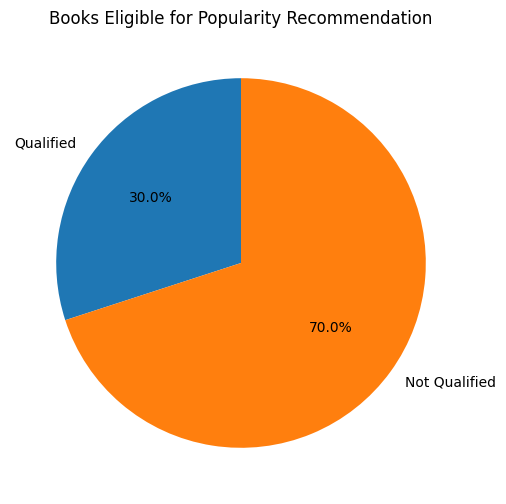

In [ ]:
labels = ["Qualified", "Not Qualified"]
sizes = [len(qualified_books),len(books) - len(qualified_books)]
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Books Eligible for Popularity Recommendation")
plt.show()

In [ ]:
def weighted_rating(x, m=m, C=C):
    v = x["numRatings"]
    R = x["rating"]
    return ((v/(v+m))*R) + ((m/(v+m))*C)

In [ ]:
qualified_books["score"] = qualified_books.apply(
    weighted_rating,
    axis=1
)

In [ ]:
qualified_books = qualified_books.sort_values(
    by="score",
    ascending=False
)
qualified_books.head()

,bookId,title,author,series,genres,description,publisher,language,rating,numRatings,likedPercent,coverImg,combined_features,score
626,17332218-words-of-radiance,words of radiance,brandon sanderson goodreads author,the stormlight archive,"['fantasy', 'fiction', 'epic fantasy', 'high f...",words of radiance book two of the stormlight a...,tor books,English,4.75,207369,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'fiction', 'epic fantasy', 'high f...",4.719325
403,862041.Harry_Potter_Series_Box_Set,harry potter series box set,j k rowling,harry potter,"['fantasy', 'young adult', 'fiction', 'magic',...",over pages of harry potter and his world inclu...,arthur a levine books,English,4.73,251756,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.705240
6546,8.Harry_Potter_Boxed_Set_Books_1_5,harry potter boxed set books harry potter,j k rowling mary grandpr illustrator,,"['fantasy', 'young adult', 'fiction', 'magic',...",box set containing harry potter and the sorcer...,scholastic,English,4.78,52749,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.668191
254,24812.The_Complete_Calvin_and_Hobbes,the complete calvin and hobbes,bill watterson,calvin and hobbes,"['comics', 'humor', 'graphic novels', 'fiction...",box set book one book two book three calvin an...,andrews mcmeel publishing,English,4.82,34893,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['comics', 'humor', 'graphic novels', 'fiction...",4.654523
71,136251.Harry_Potter_and_the_Deathly_Hallows,harry potter and the deathly hallows,j k rowling,harry potter,"['fantasy', 'young adult', 'fiction', 'magic',...",harry potter is leaving privet drive for the l...,arthur a levine books scholastic inc,English,4.62,2811637,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.618064


In [ ]:
qualified_books[
    [
        "title",
        "author",
        "rating",
        "numRatings",
        "score"
    ]
].head(20)

,title,author,rating,numRatings,score
626,words of radiance,brandon sanderson goodreads author,4.75,207369,4.719325
403,harry potter series box set,j k rowling,4.73,251756,4.705240
6546,harry potter boxed set books harry potter,j k rowling mary grandpr illustrator,4.78,52749,4.668191
254,the complete calvin and hobbes,bill watterson,4.82,34893,4.654523
71,harry potter and the deathly hallows,j k rowling,4.62,2811637,4.618064
7943,know my name,chanel miller,4.71,55887,4.613357
339,the way of kings,brandon sanderson goodreads author,4.63,302877,4.612202
319,a court of mist and fury,sarah j maas goodreads author,4.62,332646,4.604017
2457,the essential calvin and hobbes a calvin and h...,bill watterson,4.64,111826,4.593323
1545,the harry potter collection,j k rowling mary grandpr illustrator,4.68,54860,4.586055


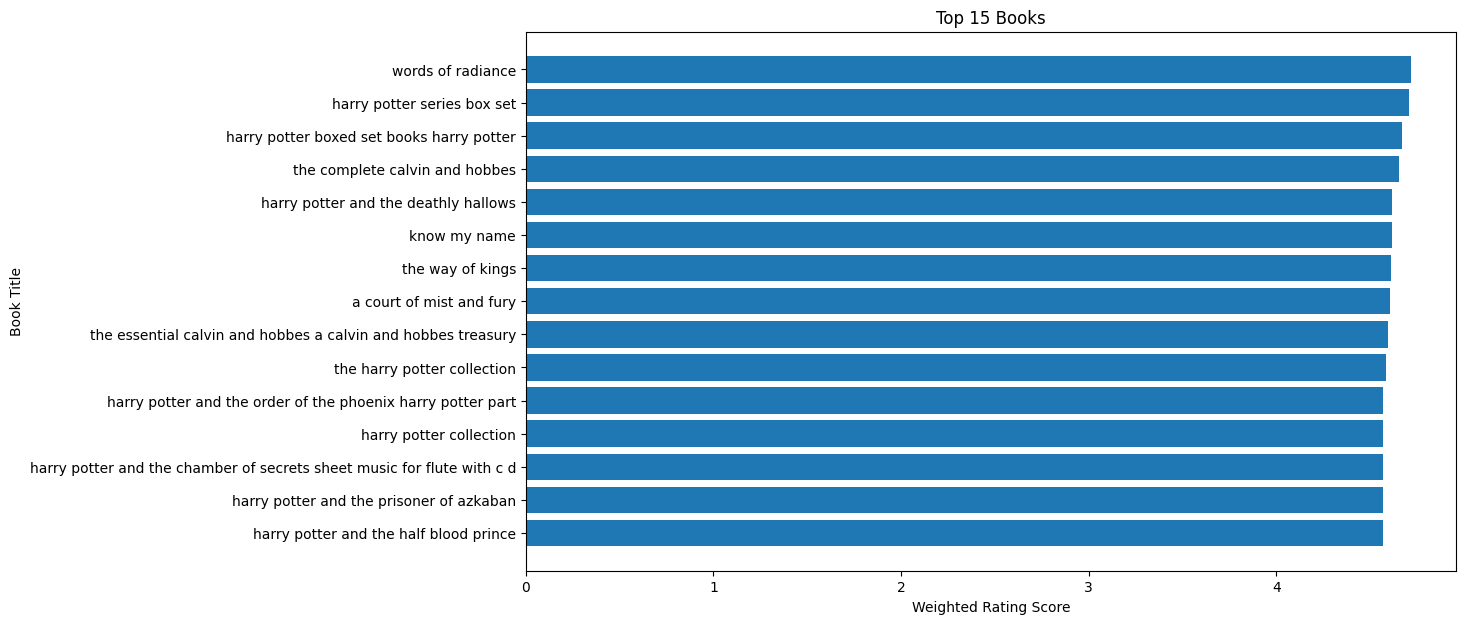

In [ ]:
top_books = qualified_books.head(15)
plt.figure(figsize=(12,7))
plt.barh(
    top_books["title"],
    top_books["score"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Books")
plt.xlabel("Weighted Rating Score")
plt.ylabel("Book Title")
plt.show()

In [ ]:
print("Books after popularity filtering:", len(qualified_books))
print("\nSample genres:")
display(qualified_books["genres"].head())
print("\nFantasy books:",
      qualified_books["genres"].str.contains(
          "fantasy",
          case=False,
          na=False
      ).sum())

Books after popularity filtering: 12695

Sample genres:


,genres
626,"['fantasy', 'fiction', 'epic fantasy', 'high f..."
403,"['fantasy', 'young adult', 'fiction', 'magic',..."
6546,"['fantasy', 'young adult', 'fiction', 'magic',..."
254,"['comics', 'humor', 'graphic novels', 'fiction..."
71,"['fantasy', 'young adult', 'fiction', 'magic',..."



Fantasy books: 5046


In [ ]:
# Remove box sets and collections from homepage popularity
exclude_patterns = (
    "box set|boxed set|collection|complete collection|"
    "omnibus|gift set|slipcase|companion"
)

qualified_books = qualified_books[
    ~qualified_books["title"].str.contains(
        exclude_patterns,
        case=False,
        na=False,
        regex=True
    )
]

In [ ]:
qualified_books = (
    qualified_books
    .sort_values("score", ascending=False)
    .drop_duplicates(subset=["title"])
    .reset_index(drop=True)
)

In [ ]:
genre_popularity = {}
top_genres = [
    "Fantasy",
    "Romance",
    "Young Adult",
    "Mystery",
    "Classics",
    "Science Fiction",
    "Historical Fiction",
    "Thriller",
    "Adventure",
    "Horror"
]
for genre in top_genres:
    genre_books = qualified_books[
        qualified_books["genres"].str.contains(
            genre,
            case=False,
            na=False
        )
    ].head(30)
    genre_popularity[genre] = genre_books

In [ ]:
print("Qualified books:", len(qualified_books))

Qualified books: 12250


In [ ]:
qualified_books[["title", "score"]].head(10)

,title,score
0,words of radiance,4.719325
1,the complete calvin and hobbes,4.654523
2,harry potter and the deathly hallows,4.618064
3,know my name,4.613357
4,the way of kings,4.612202
5,a court of mist and fury,4.604017
6,the essential calvin and hobbes a calvin and h...,4.593323
7,harry potter and the order of the phoenix harr...,4.568826
8,harry potter and the chamber of secrets sheet ...,4.568339
9,harry potter and the prisoner of azkaban,4.568221


In [ ]:
print(genre_popularity.keys())

dict_keys(['Fantasy', 'Romance', 'Young Adult', 'Mystery', 'Classics', 'Science Fiction', 'Historical Fiction', 'Thriller', 'Adventure', 'Horror'])


In [ ]:
genre_popularity["Mystery"][["title", "author"]].head()

,title,author
38,skin game,jim butcher goodreads author
63,where the crawdads sing,delia owens goodreads author
74,the complete sherlock holmes,arthur conan doyle
80,changes,jim butcher goodreads author
97,the green mile,stephen king goodreads author


In [ ]:
for genre in genre_popularity:
    print(f"{genre}: {len(genre_popularity[genre])}")

Fantasy: 30
Romance: 30
Young Adult: 30
Mystery: 30
Classics: 30
Science Fiction: 30
Historical Fiction: 30
Thriller: 30
Adventure: 30
Horror: 30


In [ ]:
print("Books after popularity filtering:", len(qualified_books))
qualified_books.head(3)

Books after popularity filtering: 12250


,bookId,title,author,series,genres,description,publisher,language,rating,numRatings,likedPercent,coverImg,combined_features,score
0,17332218-words-of-radiance,words of radiance,brandon sanderson goodreads author,the stormlight archive,"['fantasy', 'fiction', 'epic fantasy', 'high f...",words of radiance book two of the stormlight a...,tor books,English,4.75,207369,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'fiction', 'epic fantasy', 'high f...",4.719325
1,24812.The_Complete_Calvin_and_Hobbes,the complete calvin and hobbes,bill watterson,calvin and hobbes,"['comics', 'humor', 'graphic novels', 'fiction...",box set book one book two book three calvin an...,andrews mcmeel publishing,English,4.82,34893,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['comics', 'humor', 'graphic novels', 'fiction...",4.654523
2,136251.Harry_Potter_and_the_Deathly_Hallows,harry potter and the deathly hallows,j k rowling,harry potter,"['fantasy', 'young adult', 'fiction', 'magic',...",harry potter is leaving privet drive for the l...,arthur a levine books scholastic inc,English,4.62,2811637,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.618064


In [ ]:
qualified_books[["title", "score"]].head(15)

,title,score
0,words of radiance,4.719325
1,the complete calvin and hobbes,4.654523
2,harry potter and the deathly hallows,4.618064
3,know my name,4.613357
4,the way of kings,4.612202
5,a court of mist and fury,4.604017
6,the essential calvin and hobbes a calvin and h...,4.593323
7,harry potter and the order of the phoenix harr...,4.568826
8,harry potter and the chamber of secrets sheet ...,4.568339
9,harry potter and the prisoner of azkaban,4.568221


In [ ]:
qualified_books["genres"].head(10)

,genres
0,"['fantasy', 'fiction', 'epic fantasy', 'high f..."
1,"['comics', 'humor', 'graphic novels', 'fiction..."
2,"['fantasy', 'young adult', 'fiction', 'magic',..."
3,"['nonfiction', 'memoir', 'feminism', 'audioboo..."
4,"['fantasy', 'fiction', 'epic fantasy', 'high f..."
5,"['fantasy', 'romance', 'young adult', 'new adu..."
6,"['comics', 'humor', 'graphic novels', 'fiction..."
7,"['fantasy', 'fiction', 'young adult', 'magic',..."
8,"['fantasy', 'fiction', 'young adult', 'magic',..."
9,"['fantasy', 'young adult', 'fiction', 'magic',..."


In [ ]:
import pickle
import os

qualified_books.to_csv(
    "/content/drive/MyDrive/BookVerse/models/popularity_model.csv",
    index=False
)

with open(
    "/content/drive/MyDrive/BookVerse/models/genre_popularity.pkl",
    "wb"
) as f:
    pickle.dump(genre_popularity, f)